In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

Calculate the median salary by job title

In [ ]:
# filter for non NA values

filtered_df = df.loc[
    df["salary_year_avg"].notna(),
    ["job_title_short", "salary_year_avg"]
]

In [17]:
# calculate median yearly salary by job title

agg_df = filtered_df.groupby("job_title_short").agg(
    median_yearly_salary=("salary_year_avg", "median")
).reset_index().sort_values(by="median_yearly_salary")

agg_df

,job_title_short,median_yearly_salary
0,Business Analyst,85000.0
1,Cloud Engineer,90000.0
2,Data Analyst,90000.0
9,Software Engineer,99150.0
5,Machine Learning Engineer,106415.0
6,Senior Data Analyst,111175.0
3,Data Engineer,125000.0
4,Data Scientist,127500.0
7,Senior Data Engineer,147500.0
8,Senior Data Scientist,155500.0


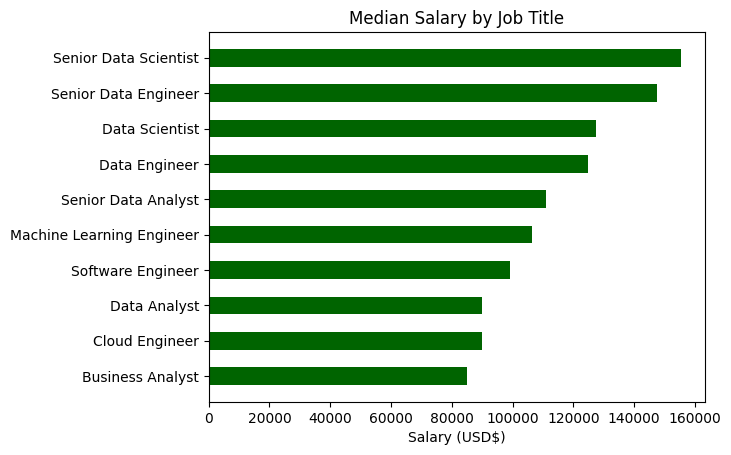

In [28]:
plt.barh(agg_df["job_title_short"], agg_df["median_yearly_salary"], height=0.5, color="darkgreen")
plt.xlabel("Salary (USD$)")
plt.title("Median Salary by Job Title")
plt.show()